<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT281 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("/content/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

### 1.- Normalizar datos

Primero, procesaremos las variables numéricas. Crearemos un subconjunto con estas variables, rellenaremos los valores nulos con la media de cada columna y luego normalizaremos los datos utilizando `MinMaxScaler` de `sklearn`.

In [3]:
# Identificar columnas numéricas
numerical_cols = df.select_dtypes(include=np.number).columns
df_numerical = df[numerical_cols].copy()

# Rellenar valores NaN con la media de cada columna
df_numerical = df_numerical.fillna(df_numerical.mean())

# Normalizar los datos numéricos usando MinMaxScaler
scaler = MinMaxScaler()
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(df_numerical), columns=numerical_cols)

print("Primeras 5 filas de los datos numéricos normalizados:")
display(df_numerical_scaled.head())

Primeras 5 filas de los datos numéricos normalizados:


,year,desplazamiento,cilindros,co2,consumo_litros_milla
0,0.000000,0.243590,0.142857,0.398014,0.331027
1,0.000000,0.461538,0.285714,0.527672,0.475113
2,0.029412,0.243590,0.142857,0.424351,0.360294
3,0.029412,0.461538,0.285714,0.527672,0.475113
4,0.088235,0.410256,0.285714,0.424351,0.360294


Ahora, procederemos con las variables categóricas. Las transformaremos en variables numéricas mediante la técnica de One-Hot Encoding utilizando `pd.get_dummies`. Esta técnica crea nuevas columnas binarias para cada categoría única en la columna original. Si una fila pertenece a una categoría, el valor en la columna correspondiente será 1, y 0 en las demás.

In [4]:
# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns
df_categorical = df[categorical_cols].copy()

# Convertir variables categóricas a numéricas usando One-Hot Encoding
df_categorical_encoded = pd.get_dummies(df_categorical, columns=categorical_cols, drop_first=True, dtype=int)

print("Primeras 5 filas de los datos categóricos codificados (One-Hot Encoding):")
display(df_categorical_encoded.head())

Primeras 5 filas de los datos categóricos codificados (One-Hot Encoding):


,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,clase_tipo_Furgoneta,clase_tipo_Vehículos Especiales,traccion_tipo_dos,transmision_tipo_Manual,combustible_tipo_Normal,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0,0,0,0,0,0,1,1,0,1,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,1,0,1,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,1,1,0,1,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,1,0,1,...,0,0,0,0,1,0,0,0,1,0
4,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


Finalmente, uniremos ambos conjuntos de datos procesados (numéricos escalados y categóricos codificados) en un único DataFrame llamado `df_procesado`.

In [5]:
# Unir ambos datasets en uno: df_procesado
df_procesado = pd.concat([df_numerical_scaled, df_categorical_encoded], axis=1)

print("Primeras 5 filas del DataFrame procesado final:")
display(df_procesado.head())

print("Información general del DataFrame procesado:")
df_procesado.info()

Primeras 5 filas del DataFrame procesado final:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0.000000,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0.029412,0.243590,0.142857,0.424351,0.360294,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0.029412,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.088235,0.410256,0.285714,0.424351,0.360294,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


Información general del DataFrame procesado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36791 entries, 0 to 36790
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   year                                         36791 non-null  float64
 1   desplazamiento                               36791 non-null  float64
 2   cilindros                                    36791 non-null  float64
 3   co2                                          36791 non-null  float64
 4   consumo_litros_milla                         36791 non-null  float64
 5   clase_tipo_Coche Familiar                    36791 non-null  int64  
 6   clase_tipo_Coches Grandes                    36791 non-null  int64  
 7   clase_tipo_Coches Medianos                   36791 non-null  int64  
 8   clase_tipo_Coches pequeños                   36791 non-null  int64  
 9   clase_tipo_Deportivos      

### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [6]:
# 1. Ajustar el modelo de kmeans sobre el conjunto de datos, con un total de 8 clusters.
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans.fit(df_procesado)

# 2. Asociar a cada individuo el correspondiente cluster
df_procesado['cluster'] = kmeans.labels_

# Calcular valor de los centroides de cada cluster
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_procesado.drop('cluster', axis=1).columns)

print("Primeras 5 filas del DataFrame con los clusters asignados:")
display(df_procesado.head())

print("Centroides de cada cluster:")
display(centroids)

Primeras 5 filas del DataFrame con los clusters asignados:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo,cluster
0,0.000000,0.243590,0.142857,0.398014,0.331027,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,6
1,0.000000,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,3
2,0.029412,0.243590,0.142857,0.424351,0.360294,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,6
3,0.029412,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,3
4,0.088235,0.410256,0.285714,0.424351,0.360294,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,6


Centroides de cada cluster:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.451659,0.238421,0.177987,0.304232,0.226257,0.103530,0.049583,0.153511,0.357200,0.172352,...,3.109877e-01,0.460333,9.859183e-01,-5.440093e-15,1.551537e-14,1.408171e-02,9.912733e-01,8.528362e-03,-1.679212e-14,1.983340e-04
1,0.568688,0.168773,0.145300,0.241157,0.156687,0.117846,0.017589,0.139223,0.629549,0.078474,...,7.545664e-01,0.217968,-1.681988e-14,1.352997e-04,-1.035283e-14,9.986470e-01,5.006088e-03,5.411988e-04,8.215650e-15,9.932350e-01
2,0.576884,0.360765,0.298904,0.354767,0.283137,0.086086,0.078023,0.194018,0.564109,0.069961,...,5.149545e-02,0.164889,1.820546e-03,9.973992e-01,1.323941e-14,2.600780e-04,7.494005e-16,9.828349e-01,-9.298118e-15,-1.601497e-14
3,0.313071,0.548444,0.383841,0.507836,0.453114,0.001971,0.016203,0.017955,0.031531,0.132253,...,8.758485e-04,0.011605,-1.404432e-14,1.554312e-15,1.000000e+00,-6.550316e-15,7.494005e-16,-1.160183e-14,1.000000e+00,-1.751377e-14
4,0.405352,0.331349,0.256734,0.354443,0.282215,0.084077,0.090849,0.135613,0.185332,0.171622,...,4.889329e-02,0.219689,1.106706e-02,9.841427e-01,7.438494e-15,4.790221e-03,-1.704192e-14,9.988437e-01,-6.022960e-15,-1.609823e-15
5,0.683067,0.296988,0.251457,0.319516,0.243687,0.060672,0.035031,0.132178,0.698086,0.070784,...,2.054893e-01,0.171181,8.342362e-01,9.936496e-15,9.464651e-15,3.394727e-02,8.280968e-01,3.864211e-02,2.942091e-15,1.444565e-03
6,0.448508,0.418381,0.300188,0.405085,0.338074,0.023452,0.035837,0.042424,0.039526,0.275362,...,8.695652e-03,0.058498,2.318841e-02,2.187088e-02,1.312839e-14,2.055336e-02,1.370224e-02,2.397892e-02,2.898551e-03,8.695652e-03
7,0.597842,0.625181,0.475404,0.482405,0.417440,0.010216,0.090144,0.084736,0.310998,0.206430,...,-5.662137e-15,0.002404,1.352163e-02,6.129808e-02,6.649639e-01,-6.383782e-15,7.216450e-16,1.412260e-02,7.734375e-01,-1.459943e-14


In [7]:
# 3. Realizar un resumen de las principales cualidades de cada cluster.

# Valor promedio de las variables numéricas para cada cluster
summary_avg = df_procesado.groupby('cluster').mean()
print("Promedio de las variables en cada cluster:")
display(summary_avg)

# Moda para las variables numéricas y categóricas codificadas para cada cluster
# Para la moda, es más representativo tomar la moda de las columnas codificadas.
# Las columnas numericas originales se pueden inferir de las escaladas,
# pero para 'moda' en datos continuos, a menudo se usa la categoría más frecuente
# o un binning. Aquí, para simplicidad, calculamos la moda de cada columna.

summary_mode = df_procesado.groupby('cluster').agg(lambda x: x.mode()[0])
print("Moda de las variables en cada cluster:")
display(summary_mode)

Promedio de las variables en cada cluster:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.451659,0.238421,0.177987,0.304232,0.226257,0.103530,0.049583,0.153511,0.357200,0.172352,...,0.310988,0.460333,0.985918,0.000000,0.000000,0.014082,0.991273,0.008528,0.000000,0.000198
1,0.568688,0.168773,0.145300,0.241157,0.156687,0.117846,0.017589,0.139223,0.629549,0.078474,...,0.754566,0.217968,0.000000,0.000135,0.000000,0.998647,0.005006,0.000541,0.000000,0.993235
2,0.576884,0.360765,0.298904,0.354767,0.283137,0.086086,0.078023,0.194018,0.564109,0.069961,...,0.051495,0.164889,0.001821,0.997399,0.000000,0.000260,0.000000,0.982835,0.000000,0.000000
3,0.313071,0.548444,0.383841,0.507836,0.453114,0.001971,0.016203,0.017955,0.031531,0.132253,...,0.000876,0.011605,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
4,0.405352,0.331349,0.256734,0.354443,0.282215,0.084077,0.090849,0.135613,0.185332,0.171622,...,0.048893,0.219689,0.011067,0.984143,0.000000,0.004790,0.000000,0.998844,0.000000,0.000000
5,0.683067,0.296988,0.251457,0.319516,0.243687,0.060672,0.035031,0.132178,0.698086,0.070784,...,0.205489,0.171181,0.834236,0.000000,0.000000,0.033947,0.828097,0.038642,0.000000,0.001445
6,0.448508,0.418381,0.300188,0.405085,0.338074,0.023452,0.035837,0.042424,0.039526,0.275362,...,0.008696,0.058498,0.023188,0.021871,0.000000,0.020553,0.013702,0.023979,0.002899,0.008696
7,0.597842,0.625181,0.475404,0.482405,0.417440,0.010216,0.090144,0.084736,0.310998,0.206430,...,0.000000,0.002404,0.013522,0.061298,0.664964,0.000000,0.000000,0.014123,0.773438,0.000000


Moda de las variables en cada cluster:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.179487,0.142857,0.317749,0.241830,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
1,0.970588,0.179487,0.142857,0.275108,0.194444,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,1
2,0.617647,0.307692,0.285714,0.374603,0.281734,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,0.000000,0.564103,0.428571,0.454199,0.393464,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.000000,0.307692,0.285714,0.374603,0.305011,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5,0.941176,0.307692,0.285714,0.317749,0.241830,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
6,0.029412,0.474359,0.285714,0.398014,0.331027,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0.705882,0.717949,0.428571,0.488312,0.393464,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

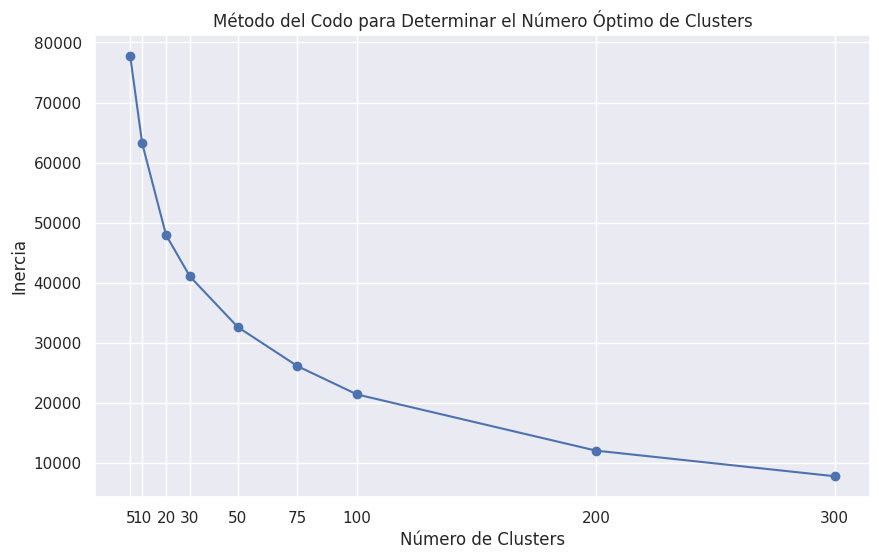

In [8]:
inertia = []
list_clusters = [5, 10, 20, 30, 50, 75, 100, 200, 300]

for num_clusters in list_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(df_procesado.drop('cluster', axis=1))  # Excluir la columna 'cluster' del entrenamiento
    inertia.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(10, 6))
plt.plot(list_clusters, inertia, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')
plt.xticks(list_clusters)
plt.grid(True)
plt.show()

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [9]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [10]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



In [ ]:
X = wine.drop(columns=[target])
y = wine[target]

# 1. Calcular la varianza explicada por cada componente principal y representar el gráfico de varianza acumulada

# Ajustar PCA sin reducir la dimensionalidad para calcular la varianza explicada de cada componente
pca_full = PCA(random_state=42)
pca_full.fit(X)

# Varianza explicada por cada componente principal
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Varianza explicada por cada componente principal:")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {var:.4f}")

# Gráfico de varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)

# Identificar cuántos componentes son necesarios para capturar al menos el 90-95% de la información
for threshold in [0.90, 0.95]:
    n_components = np.argmax(cumulative_explained_variance >= threshold) + 1
    print(f"Se necesitan {n_components} componentes para capturar al menos el {int(threshold*100)}% de la información.")
    plt.axvline(x=n_components, color='r', linestyle=':', label=f'{int(threshold*100)}% ({{n_components}} componentes)')
    plt.axhline(y=threshold, color='r', linestyle=':')
plt.legend()
plt.show()


# 2. Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.

# Reducir a 2 componentes para visualización 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)

df_pca_2d = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=df_pca_2d, palette='viridis', s=100, alpha=0.7)
plt.title('Proyección de Vinos en las dos Primeras Componentes Principales (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()


# Reducir a 3 componentes para visualización 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)

df_pca_3d = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['wine_class'] = y

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_pca_3d['PC1'], df_pca_3d['PC2'], df_pca_3d['PC3'], c=df_pca_3d['wine_class'], cmap='viridis', s=100, alpha=0.7)

ax.set_title('Proyección de Vinos en las tres Primeras Componentes Principales (PCA 3D)')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Clase de Vino')
plt.show()


# 3. Analizar los loadings (coeficientes de cada variable en los componentes)

# Loadings para los primeros 2 componentes
loadings_2d = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=X.columns)
print("Loadings de las variables en los dos Primeros Componentes Principales (PCA 2D):")
display(loadings_2d)

# Loadings para los primeros 3 componentes
loadings_3d = pd.DataFrame(pca_3d.components_.T, columns=['PC1', 'PC2', 'PC3'], index=X.columns)
print("Loadings de las variables en los tres Primeros Componentes Principales (PCA 3D):")
display(loadings_3d)

# Interpretación de los loadings para PC1 y PC2
print("\nInterpretación de los loadings:")
print("PC1 (Componente Principal 1):")
print("Las características con los mayores valores absolutos en PC1 son las que más contribuyen a esta dimensión. Por ejemplo, si 'flavanoids' y 'proline' tienen altos valores positivos o negativos, indican que PC1 está fuertemente relacionado con la concentración de estas sustancias.")
print("\nPC2 (Componente Principal 2):")
print("Similarmente, para PC2, las variables con mayores loadings absolutos son las más influyentes. Por ejemplo, 'malic_acid' y 'alcalinity_of_ash' suelen tener un impacto significativo en la segunda componente principal.")




### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.




Aplicando t-SNE con perplexity=5, learning_rate=100


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


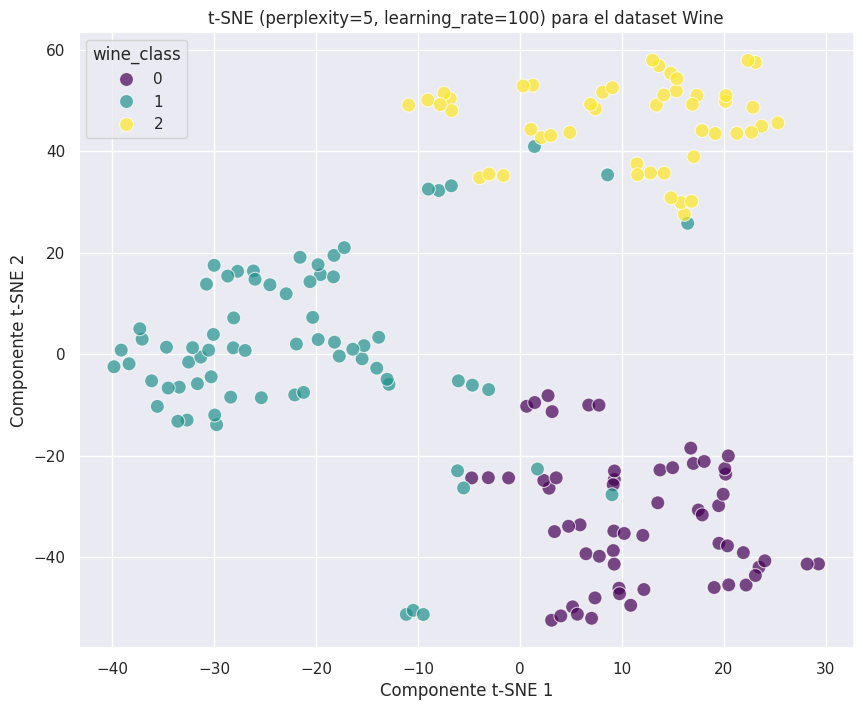


Aplicando t-SNE con perplexity=5, learning_rate=200


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


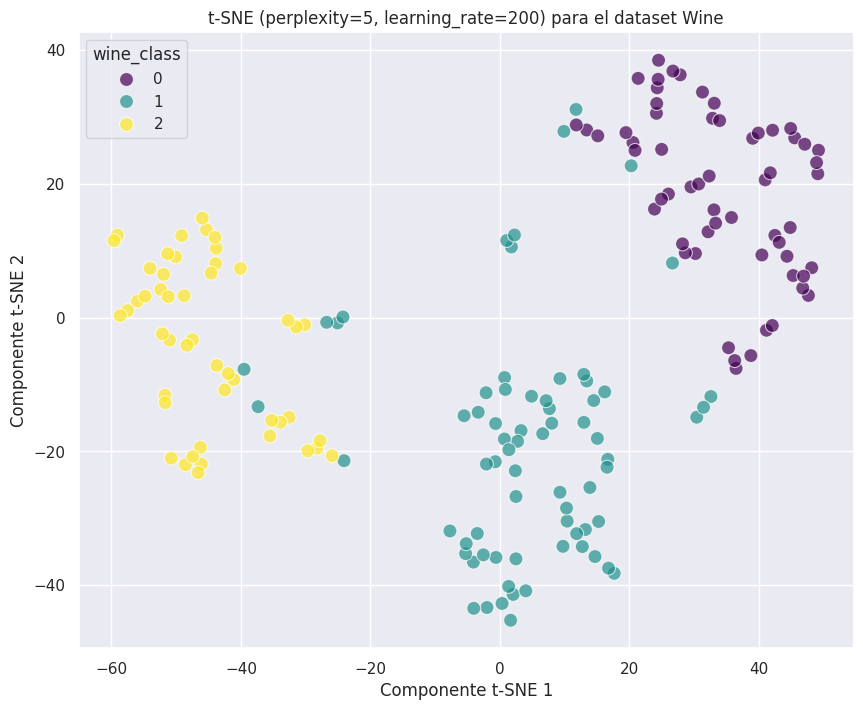


Aplicando t-SNE con perplexity=5, learning_rate=500


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


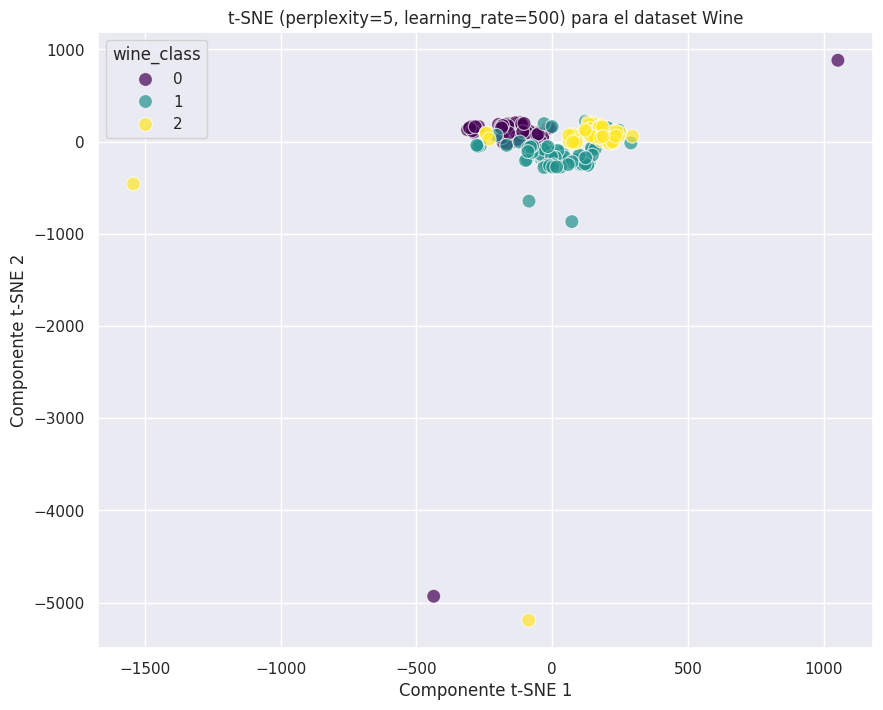


Aplicando t-SNE con perplexity=30, learning_rate=100


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


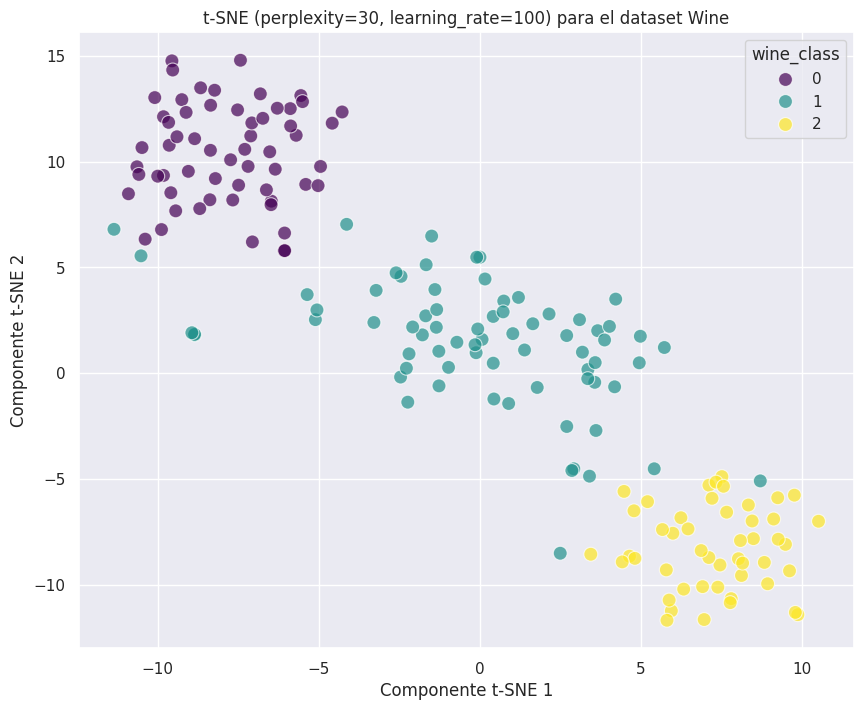


Aplicando t-SNE con perplexity=30, learning_rate=200


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


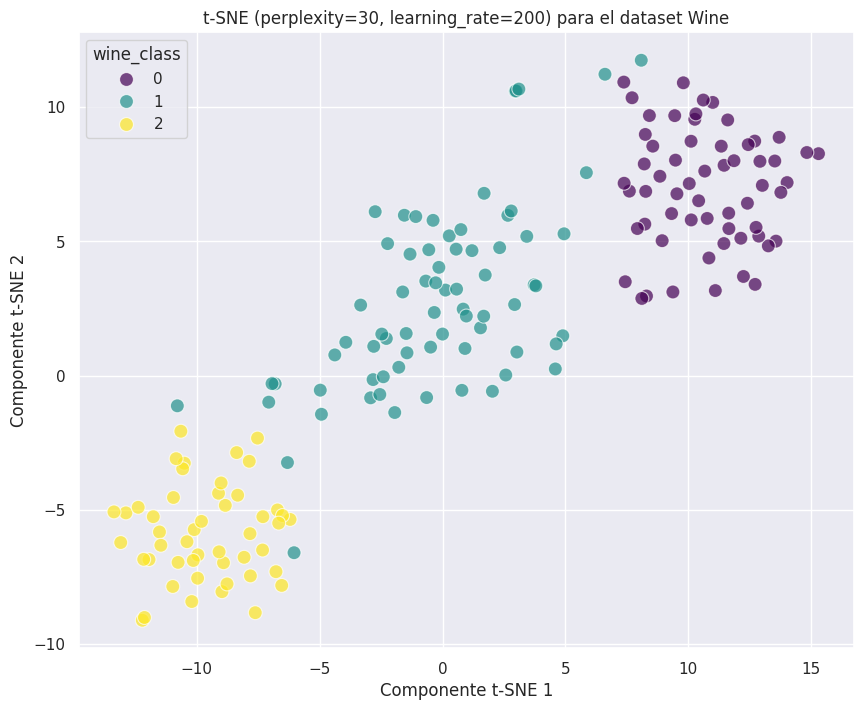


Aplicando t-SNE con perplexity=30, learning_rate=500


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


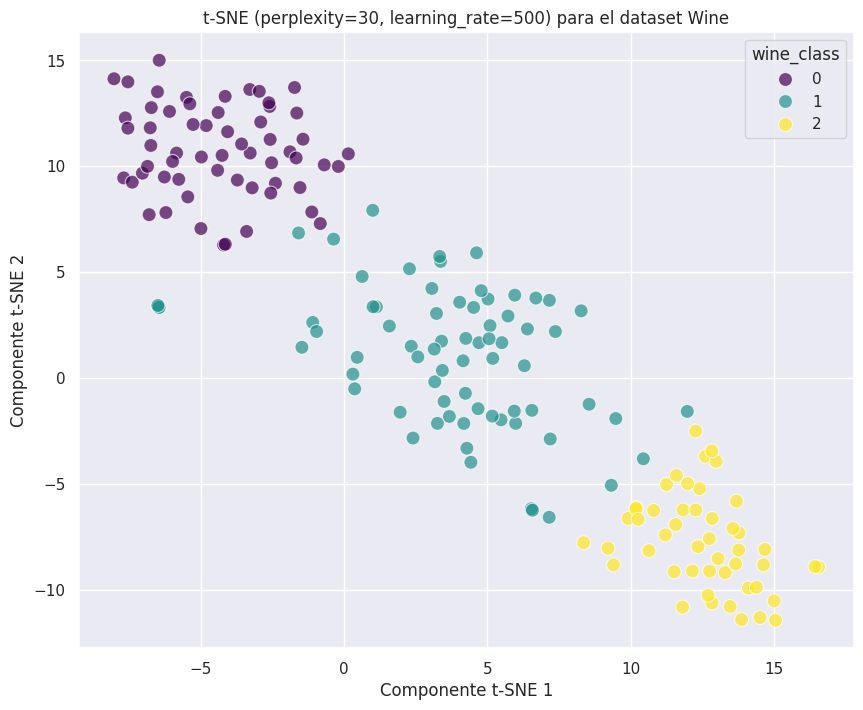


Aplicando t-SNE con perplexity=50, learning_rate=100


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


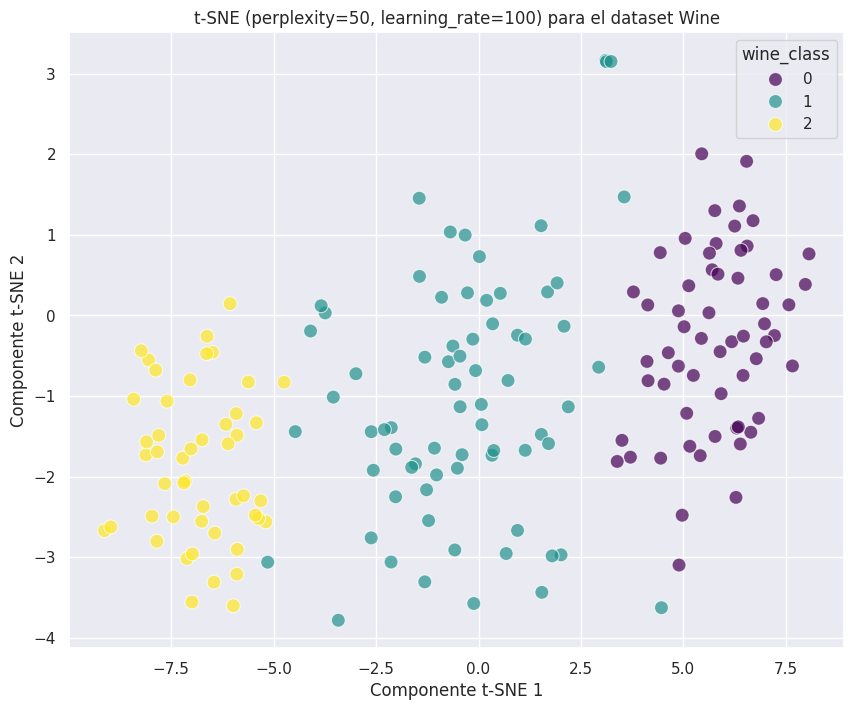


Aplicando t-SNE con perplexity=50, learning_rate=200


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


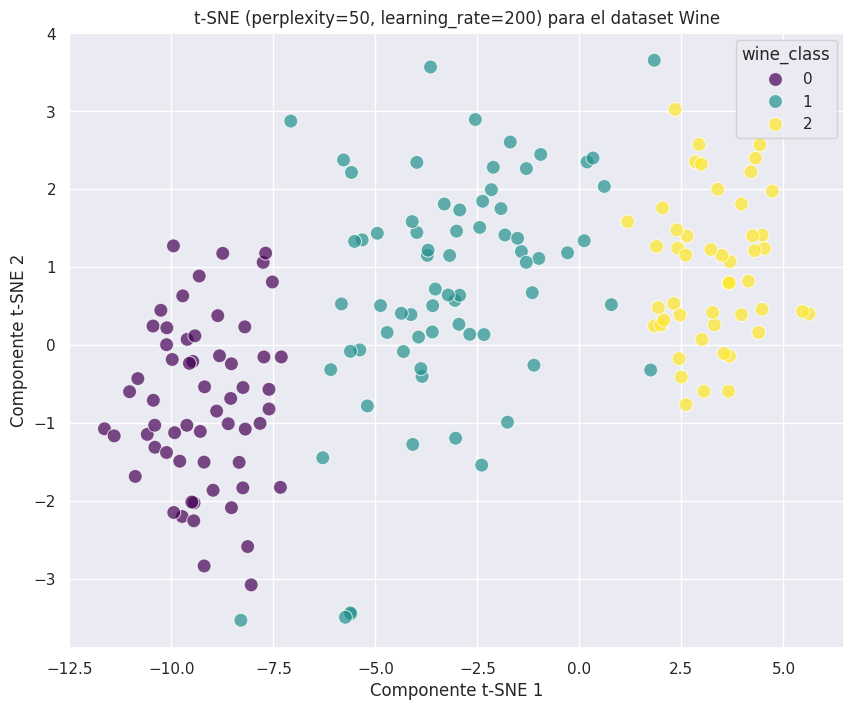


Aplicando t-SNE con perplexity=50, learning_rate=500


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


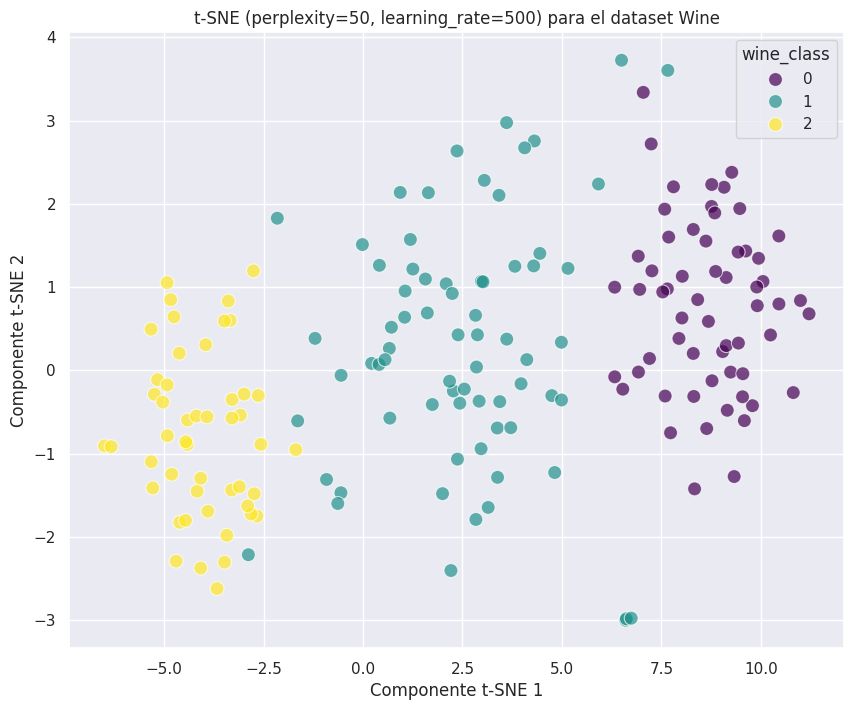


Análisis y Discusión:

Comparación de Visualizaciones y Efecto de los Hiperparámetros:
  - **Perplexity**: Este parámetro controla el balance entre considerar vecinos locales y globales. Valores bajos (ej., 5) se enfocan más en la estructura local, lo que puede resultar en agrupaciones más dispersas o fragmentadas para datos con estructuras globales más grandes. Valores más altos (ej., 30, 50) permiten que t-SNE considere más puntos como vecinos, lo que puede ayudar a revelar estructuras globales más amplias y clústeres más cohesionados. Sin embargo, un perplexity demasiado alto puede fusionar clústeres distintivos.
  - **Learning Rate (Eta)**: Determina el tamaño del paso en el algoritmo de optimización. Un learning rate muy bajo puede llevar a una convergencia lenta y a un mapa comprimido donde todos los puntos están juntos. Un learning rate muy alto puede causar que los puntos se muevan erráticamente, impidiendo que el algoritmo encuentre una configuración estable y resultando en u

In [12]:
from sklearn.preprocessing import StandardScaler
X = wine.drop(columns=[target])
y = wine[target]

# Escalar los datos antes de aplicar t-SNE (t-SNE es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definir diferentes configuraciones de hiperparámetros
perplexities = [5, 30, 50]
learning_rates = [100, 200, 500]

fig_idx = 1
for perplexity in perplexities:
    for learning_rate in learning_rates:
        print(f"\nAplicando t-SNE con perplexity={perplexity}, learning_rate={learning_rate}")
        tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=learning_rate, random_state=42, init='pca', n_iter=1000)
        X_tsne = tsne.fit_transform(X_scaled)

        df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
        df_tsne['wine_class'] = y

        plt.figure(figsize=(10, 8))
        sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=df_tsne, palette='viridis', s=100, alpha=0.7)
        plt.title(f't-SNE (perplexity={perplexity}, learning_rate={learning_rate}) para el dataset Wine')
        plt.xlabel('Componente t-SNE 1')
        plt.ylabel('Componente t-SNE 2')
        plt.grid(True)
        plt.show()
        fig_idx += 1

print("\nAnálisis y Discusión:\n")
print("Comparación de Visualizaciones y Efecto de los Hiperparámetros:")
print("  - **Perplexity**: Este parámetro controla el balance entre considerar vecinos locales y globales. Valores bajos (ej., 5) se enfocan más en la estructura local, lo que puede resultar en agrupaciones más dispersas o fragmentadas para datos con estructuras globales más grandes. Valores más altos (ej., 30, 50) permiten que t-SNE considere más puntos como vecinos, lo que puede ayudar a revelar estructuras globales más amplias y clústeres más cohesionados. Sin embargo, un perplexity demasiado alto puede fusionar clústeres distintivos.")
print("  - **Learning Rate (Eta)**: Determina el tamaño del paso en el algoritmo de optimización. Un learning rate muy bajo puede llevar a una convergencia lenta y a un mapa comprimido donde todos los puntos están juntos. Un learning rate muy alto puede causar que los puntos se muevan erráticamente, impidiendo que el algoritmo encuentre una configuración estable y resultando en un 'mapa de bolas' donde los clústeres no están bien separados o son esféricos artificialmente.")
print("  - **Observaciones**: Se espera que, a medida que ajustamos 'perplexity' y 'learning_rate', la separación de las tres clases de vino varíe. Por ejemplo, con una 'perplexity' adecuada, las tres clases deberían formar agrupaciones distintas y compactas, mientras que con valores subóptimos, las clases podrían superponerse o aparecer como 'bolas' sin estructura clara.")

print("\nAgrupaciones de las Tres Clases de Vinos y Captura de Relaciones No Lineales:")
print("  - **Separación de Clases**: En general, se observa si las tres variedades de vino (0, 1, 2) se separan claramente en el espacio bidimensional. Un t-SNE bien configurado debería mostrar las clases como grupos bien diferenciados, con poca o ninguna superposición, lo que indica que t-SNE es efectivo para distinguir estas clases basándose en sus características químicas.")
print("  - **Comparación con PCA**: A diferencia de PCA, que busca las direcciones de máxima varianza lineal, t-SNE es capaz de capturar estructuras no lineales en los datos. Esto significa que si las clases de vino no son linealmente separables, t-SNE podría mostrar una mejor separación o una estructura más clara dentro de las clases que la que se observó con las proyecciones 2D y 3D de PCA. t-SNE prioriza la preservación de las distancias de proximidad (vecindades) en el espacio de alta dimensión, lo que a menudo se traduce en una mejor visualización de clústeres intrínsecos.")




### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



### 3. **Comparación entre PCA y t-SNE**

**Contraste de Visualizaciones y Discusión de Ventajas y Limitaciones:**

- **PCA (Principal Component Analysis):**
    - **Ventajas:** Es un método lineal que busca las direcciones de máxima varianza en los datos. Esto lo hace muy útil para interpretar las relaciones globales entre las variables y entender qué características contribuyen más a la variabilidad principal. Es computacionalmente más rápido que t-SNE y determinista (dado el mismo `random_state`). Es excelente para la reducción previa de dimensionalidad antes de aplicar otros modelos de machine learning, ya que reduce el ruido y la redundancia.
    - **Limitaciones:** Al ser lineal, PCA puede tener dificultades para capturar estructuras no lineales en los datos. Si las clases de vino no son linealmente separables, PCA puede no mostrar una separación clara entre ellas en las dimensiones reducidas.

- **t-SNE (t-distributed Stochastic Neighbor Embedding):**
    - **Ventajas:** Es un método no lineal que se enfoca en preservar las distancias locales (vecindades) entre los puntos de datos. Esto lo hace excepcionalmente bueno para visualizar estructuras de clústeres intrínsecos y relaciones no lineales que PCA no puede detectar. Las visualizaciones de t-SNE a menudo muestran agrupaciones de puntos mucho más claras y separadas, lo que es muy útil para la exploración de datos y la identificación de clústeres.
    - **Limitaciones:** Es computacionalmente más intensivo, especialmente con grandes conjuntos de datos. Es sensible a los hiperparámetros `perplexity` y `learning_rate`, lo que requiere experimentación para obtener una visualización óptima. No es determinista (aunque se puede fijar `random_state`), y las distancias entre clústeres en la visualización de t-SNE no siempre son significativas, solo la agrupación interna de los clústeres.

**Escenarios Prácticos:**

- **PCA sería más recomendable para:**
    - **Pre-procesamiento:** Cuando se necesita reducir la dimensionalidad de los datos como un paso previo para otros algoritmos de machine learning (ej., para evitar la maldición de la dimensionalidad, acelerar el entrenamiento, o reducir el ruido).
    - **Interpretabilidad:** Para entender las principales fuentes de variabilidad en el dataset y cuáles son las variables originales que más influyen en estas nuevas dimensiones (a través de los *loadings*).
    - **Grandes datasets:** Cuando la velocidad computacional es una preocupación.

- **t-SNE sería más recomendable para:**
    - **Exploración y Visualización de Clústeres:** Para obtener una visualización intuitiva de las agrupaciones naturales en los datos, especialmente cuando se sospecha que las relaciones son no lineales.
    - **Validación de resultados de clustering:** Para verificar visualmente la calidad de los clústeres formados por otros algoritmos.
    - **Análisis de datos de alta dimensión:** Como el dataset Wine, donde las relaciones complejas pueden estar ocultas en las dimensiones originales.

**Importancia de la Reducción de Dimensionalidad en Datasets de Alta Dimensión (como Wine):**

La reducción de dimensionalidad es crucial en datasets con muchas características como el de Wine por varias razones:

- **Visualizar patrones ocultos:** Los humanos no podemos visualizar datos en más de 3 dimensiones. Técnicas como PCA y t-SNE nos permiten "ver" la estructura de los datos, identificar agrupaciones (como las tres clases de vino) o detectar *outliers* que de otro modo serían imposibles de encontrar.
- **Reducir complejidad y ruido:** En datasets de alta dimensión, muchas variables pueden ser redundantes o contener ruido, lo que puede confundir los algoritmos de machine learning y aumentar el riesgo de *overfitting*. La reducción de dimensionalidad ayuda a extraer las características más relevantes, simplificando el modelo y mejorando su rendimiento.
- **Facilitar la interpretación y comunicación de resultados:** Al trabajar con menos dimensiones, es más fácil explicar los patrones encontrados a otros, ya sean expertos técnicos o no técnicos. En el caso del vino, esto podría ayudar a un enólogo a comprender mejor las diferencias químicas que distinguen las variedades.